# Practice with data set

1. Train a CNN on crater dataset.
2. Compare Random Forest vs Neural Network.
3. Create simple surrogate model for physics equation.



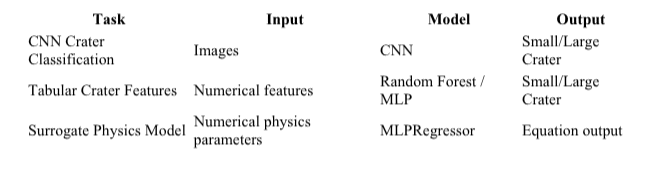

# Train a CNN on a Crater Dataset

We simulate crater image data using random numbers for demonstration. In practice, you would
use real satellite or lunar crater images. Explanation:

* Conv2D + MaxPooling2D = Extract spatial features
(edges, shapes) from crater
images.
* Flatten + Dense = Fully connected layers for classification.
* Sigmoid activation = Produces a probability for binary classification (small vs large
crater).
* Training = Model learns features from images to predict crater size.

In [1]:
# Import libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
# Example: 1000 images, 64x64 pixels, RGB
X = np.random.rand(1000, 64, 64, 3)
y = np.random.randint(0, 2, 1000)  # 0 = small crater, 1 = large crater

# Split into train/test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Define CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation=&#39;relu&#39;, input_shape=(64,64,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation=&#39;relu&#39;),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(64, activation=&#39;relu&#39;),
    layers.Dense(1, activation=&#39;sigmoid&#39;)  # Binary classification
])
# Compile model
model.compile(optimizer=&#39;adam&#39;,
              loss=&#39;binary_crossentropy&#39;,
              metrics=[&#39;accuracy&#39;])
# Train model
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.1)
# Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print(&quot;CNN Test Accuracy:&quot;, accuracy)

SyntaxError: invalid non-printable character U+00A0 (3422513601.py, line 7)

In [3]:
# Import libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

# Example: 1000 images, 64x64 pixels, RGB
X = np.random.rand(1000, 64, 64, 3)
y = np.random.randint(0, 2, 1000)  # 0 = small crater, 1 = large crater

# Split into train/test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

# Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print("CNN Test Accuracy:", accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 158ms/step - accuracy: 0.4861 - loss: 0.7902 - val_accuracy: 0.4875 - val_loss: 0.6932
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 206ms/step - accuracy: 0.5167 - loss: 0.6932 - val_accuracy: 0.5125 - val_loss: 0.6928
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - accuracy: 0.5083 - loss: 0.6917 - val_accuracy: 0.5125 - val_loss: 0.6937
Epoch 4/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 148ms/step - accuracy: 0.5125 - loss: 0.6922 - val_accuracy: 0.5125 - val_loss: 0.6930
Epoch 5/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 180ms/step - accuracy: 0.5486 - loss: 0.6892 - val_accuracy: 0.5125 - val_loss: 0.6931
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5050 - loss: 0.6939
CNN Test Accuracy: 0.5049999952316284


Compare Random Forest vs Neural Network on Tabular Crater Features

Here we simulate 10 numerical features (e.g., crater diameter, depth, albedo). Explanation:
*  Random Forest - Good for tabular data, ensemble of decision trees. Handles non-linear
relationships.
* MLPClassifier - Neural network for tabular features. Can capture more complex
relationships but requires careful tuning.
* Compare - Check accuracy to see which model performs better for crater classification.

In [5]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Simulated tabular data: 500 samples, 10 features
X = np.random.rand(500, 10)
y = np.random.randint(0, 2, 500)  # 0 = small crater, 1 = large crater

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_acc)

# Neural Network
nn_model = MLPClassifier(hidden_layer_sizes=(32,32), max_iter=500)
nn_model.fit(X_train, y_train)
nn_pred = nn_model.predict(X_test)
nn_acc = accuracy_score(y_test, nn_pred)
print("Neural Network Accuracy:", nn_acc)

Random Forest Accuracy: 0.51
Neural Network Accuracy: 0.55


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Create a Simple Surrogate Model for a Physics Equation

Suppose we want to approximate the simple physics equation:

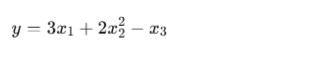

We can train an ML surrogate (neural network) to predict y from x1, x2, x3.
Explanation:
*  MLPRegressor - Neural network for regression tasks.
*  Input features - Physics parameters x1,x2,x3x_1, x_2, x_3x1​,x2​,x3​.

* Output - Approximates the physics equation, allowing fast predictions without solving
equations analytically.
* MSE - Measures the difference between true and predicted outputs.

In [6]:
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Generate synthetic data
np.random.seed(42)
X = np.random.rand(1000, 3)  # 3 input parameters
y = 3*X[:,0] + 2*X[:,1]**2 - X[:,2]  # Physics equation output

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

# Surrogate model
model = MLPRegressor(
    hidden_layer_sizes=(32,32),
    activation='relu',
    max_iter=500
)

model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
print("Surrogate model MSE:", mse)

# Example prediction
print("Example input:", X_test[:5])
print("Predicted output:", y_pred[:5])

Surrogate model MSE: 0.002330533197339807
Example input: [[0.35342138 0.23687056 0.78052552]
 [0.33300191 0.66948696 0.99413936]
 [0.39513774 0.03945953 0.47554604]
 [0.70385709 0.00436327 0.16695309]
 [0.71395263 0.82253479 0.80395851]]
Predicted output: [0.34151381 0.90117267 0.68275311 1.85427725 2.72321866]
